# Autodiff + SGD for Parameter Estimation

## A didactic example using Michaelis-Menten Enzyme Kinetics

This notebook (generated by Claude) demonstrates how to use **automatic differentiation (autodiff)** combined with **stochastic gradient descent (SGD)** to estimate parameters from data.

### The Michaelis-Menten Equation

The Michaelis-Menten equation describes enzyme kinetics:

$$v = \frac{V_{max} \cdot [S]}{K_m + [S]}$$

Where:
- $v$ = reaction velocity
- $[S]$ = substrate concentration
- $V_{max}$ = maximum reaction velocity (parameter to estimate)
- $K_m$ = Michaelis constant (parameter to estimate)

### Why Autodiff + SGD?

1. **Autodiff** automatically computes gradients of any differentiable function - no manual derivative calculation needed
2. **SGD** iteratively updates parameters in the direction that minimizes the loss function

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIGURE_DIR = Path("../../book/book/images")

# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

## Step 1: Generate Synthetic Data

We'll create "ground truth" data using known parameter values, then add noise to simulate real experimental measurements.

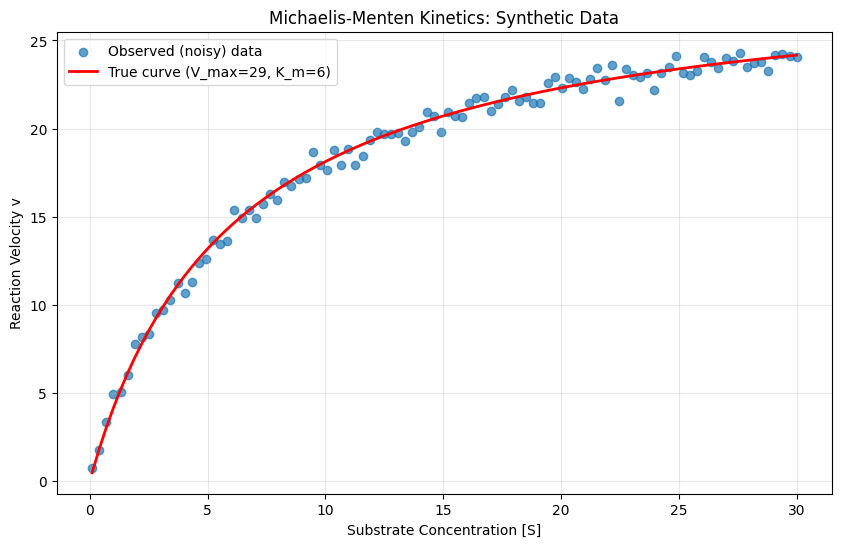

In [2]:
# True parameters (what we want to recover)
# based on values for cholinesterase from: https://pubmed.ncbi.nlm.nih.gov/6610744/

V_max_true = 29  # Maximum velocity (in nM/min)
K_m_true = 6     # Michaelis constant (in mM)
noise_sd = 0.5    # Standard deviation of noise

# Generate substrate concentration data points
S = np.linspace(0.1, 30, 100)  # Substrate concentrations

# Michaelis-Menten equation
def michaelis_menten(S, V_max, K_m):
    """
    Calculate reaction velocity using Michaelis-Menten kinetics.
    S: Substrate concentration
    V_max: Maximum reaction velocity
    K_m: Michaelis constant
    """
    
    return (V_max * S) / (K_m + S)

# Generate noisy observations
v_true = michaelis_menten(S, V_max_true, K_m_true)
noise = np.random.normal(0, noise_sd, size=v_true.shape)
v_observed = v_true + noise

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(S, v_observed, alpha=0.7, label='Observed (noisy) data')
plt.plot(S, v_true, 'r-', linewidth=2, label=f'True curve (V_max={V_max_true}, K_m={K_m_true})')
plt.xlabel('Substrate Concentration [S]')
plt.ylabel('Reaction Velocity v')
plt.title('Michaelis-Menten Kinetics: Synthetic Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "michaelis_menten_data.png")

## Step 2: Set Up PyTorch for Autodiff

PyTorch tensors with `requires_grad=True` automatically track operations for gradient computation. This is the magic of autodiff!

In [3]:
# Convert data to PyTorch tensors
S_tensor = torch.tensor(S, dtype=torch.float32)
v_observed_tensor = torch.tensor(v_observed, dtype=torch.float32)

# Initialize parameters with random guesses
# requires_grad=True enables automatic differentiation
V_max_init = 10.0
K_m_init = 10.0

V_max = torch.tensor(V_max_init, requires_grad=True)  # Initial guess
K_m = torch.tensor(K_m_init, requires_grad=True)    # Initial guess

print(f"Initial guesses: V_max = {V_max.item():.2f}, K_m = {K_m.item():.2f}")
print(f"True values:     V_max = {V_max_true:.2f}, K_m = {K_m_true:.2f}")

Initial guesses: V_max = 10.00, K_m = 10.00
True values:     V_max = 29.00, K_m = 6.00


## Step 3: Define the Loss Function

We use **Mean Squared Error (MSE)** as our loss function:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (v_{\text{predicted},i} - v_{\text{observed},i})^2$$

The goal is to find $V_{max}$ and $K_m$ that minimize this loss.

In [4]:
def compute_loss(V_max, K_m, S, v_observed):
    """Compute MSE loss between predicted and observed velocities."""
    v_predicted = michaelis_menten(S, V_max, K_m)
    loss = torch.mean((v_predicted - v_observed) ** 2)
    return loss



## Step 4: The SGD Training Loop

Here's where the magic happens! For each iteration:
1. **Forward pass**: Compute predicted values and loss
2. **Backward pass**: Autodiff computes gradients via `loss.backward()`
3. **Update**: Adjust parameters in the direction that reduces loss
4. **Zero gradients**: Clear accumulated gradients for next iteration

The update rule for SGD is:
$$\theta_{new} = \theta_{old} - \alpha \cdot \nabla_\theta L$$

Where $\alpha$ is the learning rate and $\nabla_\theta L$ is the gradient of the loss with respect to parameter $\theta$.

In [5]:
# Hyperparameters
learning_rate = 0.1
n_iterations = 500

# Storage for tracking progress
loss_history = []
V_max_history = []
K_m_history = []

# Test the loss with initial parameters
initial_loss = compute_loss(V_max, K_m, S_tensor, v_observed_tensor)
print(f"Initial loss: {initial_loss.item():.4f}")

# SGD Training Loop
for i in range(n_iterations):
    # Forward pass: compute loss
    loss = compute_loss(V_max, K_m, S_tensor, v_observed_tensor)
    
    # Store history
    loss_history.append(loss.item())
    V_max_history.append(V_max.item())
    K_m_history.append(K_m.item())
    
    # Backward pass: compute gradients via autodiff
    loss.backward()
    
    # Update parameters using SGD (gradient descent step)
    # torch.no_grad() prevents these operations from being tracked
    with torch.no_grad():
        V_max -= learning_rate * V_max.grad
        K_m -= learning_rate * K_m.grad
        
        # Zero the gradients for the next iteration
        V_max.grad.zero_()
        K_m.grad.zero_()
    
    # Print progress
    if i % 100 == 0:
        print(f"Iteration {i:3d}: Loss = {loss.item():.4f}, V_max = {V_max.item():.4f}, K_m = {K_m.item():.4f}")

print(f'Final loss: {loss.item():.4f}')
print(f"\nFinal estimates: V_max = {V_max.item():.4f}, K_m = {K_m.item():.4f}")
print(f"True values:     V_max = {V_max_true:.4f}, K_m = {K_m_true:.4f}")

Initial loss: 188.0915
Iteration   0: Loss = 188.0915, V_max = 11.5620, K_m = 9.4214
Iteration 100: Loss = 0.4665, V_max = 27.2348, K_m = 4.8899
Iteration 200: Loss = 0.2339, V_max = 28.4312, K_m = 5.6810
Iteration 300: Loss = 0.2059, V_max = 28.8495, K_m = 5.9673
Iteration 400: Loss = 0.2014, V_max = 29.0183, K_m = 6.0842
Final loss: 0.2006

Final estimates: V_max = 29.0894, K_m = 6.1336
True values:     V_max = 29.0000, K_m = 6.0000


## Step 5: Visualize the Results

Let's see how our optimization progressed and compare the fitted curve to the true curve.

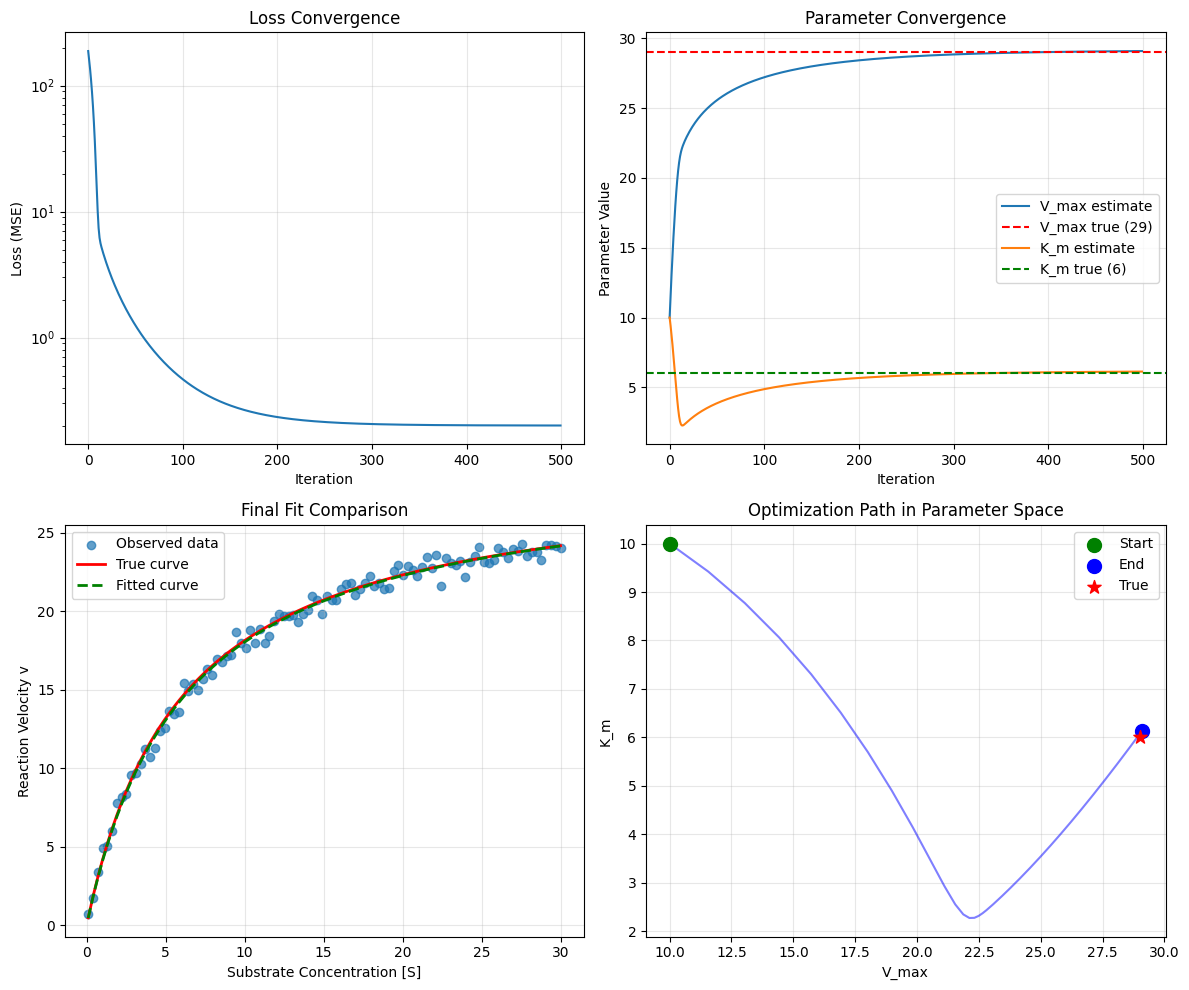

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Loss over iterations
axes[0, 0].plot(loss_history)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].set_title('Loss Convergence')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Parameter trajectories
axes[0, 1].plot(V_max_history, label='V_max estimate')
axes[0, 1].axhline(y=V_max_true, color='r', linestyle='--', label=f'V_max true ({V_max_true})')
axes[0, 1].plot(K_m_history, label='K_m estimate')
axes[0, 1].axhline(y=K_m_true, color='g', linestyle='--', label=f'K_m true ({K_m_true})')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Parameter Value')
axes[0, 1].set_title('Parameter Convergence')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Final fit vs data
v_fitted = michaelis_menten(S, V_max.item(), K_m.item())
axes[1, 0].scatter(S, v_observed, alpha=0.7, label='Observed data')
axes[1, 0].plot(S, v_true, 'r-', linewidth=2, label='True curve')
axes[1, 0].plot(S, v_fitted, 'g--', linewidth=2, label='Fitted curve')
axes[1, 0].set_xlabel('Substrate Concentration [S]')
axes[1, 0].set_ylabel('Reaction Velocity v')
axes[1, 0].set_title('Final Fit Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Parameter space trajectory
axes[1, 1].plot(V_max_history, K_m_history, 'b-', alpha=0.5)
axes[1, 1].scatter(V_max_history[0], K_m_history[0], color='green', s=100, zorder=5, label='Start')
axes[1, 1].scatter(V_max_history[-1], K_m_history[-1], color='blue', s=100, zorder=5, label='End')
axes[1, 1].scatter(V_max_true, K_m_true, color='red', s=100, marker='*', zorder=5, label='True')
axes[1, 1].set_xlabel('V_max')
axes[1, 1].set_ylabel('K_m')
axes[1, 1].set_title('Optimization Path in Parameter Space')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Parameter Uncertainty via Hessian (Fisher Information)

The **Hessian matrix** contains the second derivatives of the loss function with respect to the parameters. At the minimum, it approximates the **Fisher Information Matrix**, which is related to parameter uncertainty.

For parameter estimates $\hat{\theta}$, the covariance matrix is approximately:
$$\text{Cov}(\hat{\theta}) \approx \frac{\sigma^2}{n} \mathbf{H}^{-1}$$

Where:
- $\mathbf{H}$ = Hessian matrix (second derivatives of loss)
- $\sigma^2$ = noise variance 
- $n$ = number of data points

The **standard errors** are the square roots of the diagonal elements of the covariance matrix.

In [7]:
# Compute Hessian matrix using PyTorch's autograd
def compute_hessian(V_max, K_m, S, v_observed):
    """Compute the Hessian matrix of the loss function."""
    # Create new tensors that require gradients
    params = torch.tensor([V_max.item(), K_m.item()], requires_grad=True)
    
    # Compute loss with respect to parameter vector
    v_pred = (params[0] * S) / (params[1] + S)
    loss = torch.mean((v_pred - v_observed) ** 2)
    
    # Compute first derivatives (gradient)
    grad = torch.autograd.grad(loss, params, create_graph=True)[0]
    
    # Compute Hessian (second derivatives)
    hessian = torch.zeros(2, 2)
    for i in range(2):
        grad2 = torch.autograd.grad(grad[i], params, retain_graph=True)[0]
        hessian[i] = grad2
    
    return hessian.detach().numpy()

# Compute Hessian at the optimal point
hessian = compute_hessian(V_max, K_m, S_tensor, v_observed_tensor)
print("Hessian matrix:")
print(hessian)

# Estimate noise variance from residuals
v_fitted_final = michaelis_menten(S, V_max.item(), K_m.item())
residuals = v_observed - v_fitted_final
sigma_squared = np.var(residuals, ddof=2)  # ddof=2 for 2 estimated parameters
n_data = len(S)

print(f"\nEstimated noise variance (σ²): {sigma_squared:.4f}")
print(f"Number of data points (n): {n_data}")

# Compute covariance matrix
# Cov(θ) ≈ σ²/n * H⁻¹
try:
    hessian_inv = np.linalg.inv(hessian)
    covariance_matrix = (sigma_squared / n_data) * hessian_inv
    
    # Standard errors are square roots of diagonal elements
    V_max_se = np.sqrt(covariance_matrix[0, 0])
    K_m_se = np.sqrt(covariance_matrix[1, 1])
    
    print(f"\nCovariance matrix:")
    print(covariance_matrix)
    
    print(f"\nParameter uncertainties (standard errors):")
    print(f"V_max: {V_max.item():.4f} ± {V_max_se:.4f}")
    print(f"K_m:   {K_m.item():.4f} ± {K_m_se:.4f}")
    
    # Correlation coefficient between parameters
    correlation = covariance_matrix[0, 1] / (V_max_se * K_m_se)
    print(f"\nCorrelation between V_max and K_m: {correlation:.4f}")
    
    # Compare with true values
    V_max_error = abs(V_max.item() - V_max_true)
    K_m_error = abs(K_m.item() - K_m_true)
    
    print(f"\nActual errors:")
    print(f"V_max error: {V_max_error:.4f} (= {V_max_error/V_max_se:.1f} × SE)")
    print(f"K_m error:   {K_m_error:.4f} (= {K_m_error/K_m_se:.1f} × SE)")
    
except np.linalg.LinAlgError:
    print("Warning: Hessian matrix is singular - cannot compute parameter uncertainties")

Hessian matrix:
[[ 0.890098  -1.1586063]
 [-1.1586063  1.7469552]]

Estimated noise variance (σ²): 0.2045
Number of data points (n): 100

Covariance matrix:
[[0.01680238 0.01114358]
 [0.01114358 0.00856104]]

Parameter uncertainties (standard errors):
V_max: 29.0894 ± 0.1296
K_m:   6.1336 ± 0.0925

Correlation between V_max and K_m: 0.9291

Actual errors:
V_max error: 0.0894 (= 0.7 × SE)
K_m error:   0.1336 (= 1.4 × SE)


In [8]:
    # Compute confidence intervals
    from scipy import stats
    
    # Degrees of freedom = n_data - n_parameters
    dof = n_data - 2
    
    # t-statistics for different confidence levels
    confidence_levels = [0.90, 0.95, 0.99]  # 90%, 95%, 99%
    
    print(f"\nConfidence Intervals (df = {dof}):")
    print("=" * 50)
    
    for conf_level in confidence_levels:
        alpha = 1 - conf_level
        t_critical = stats.t.ppf(1 - alpha/2, dof)
        
        # Confidence intervals
        V_max_margin = t_critical * V_max_se
        K_m_margin = t_critical * K_m_se
        
        V_max_ci_lower = V_max.item() - V_max_margin
        V_max_ci_upper = V_max.item() + V_max_margin
        K_m_ci_lower = K_m.item() - K_m_margin
        K_m_ci_upper = K_m.item() + K_m_margin
        
        print(f"{conf_level*100:4.0f}% CI (t = {t_critical:.3f}):")
        print(f"  V_max: [{V_max_ci_lower:.4f}, {V_max_ci_upper:.4f}] (±{V_max_margin:.4f})")
        print(f"  K_m:   [{K_m_ci_lower:.4f}, {K_m_ci_upper:.4f}] (±{K_m_margin:.4f})")
        
        # Check if true values are within CI
        V_max_in_ci = V_max_ci_lower <= V_max_true <= V_max_ci_upper
        K_m_in_ci = K_m_ci_lower <= K_m_true <= K_m_ci_upper
        
        print(f"  True V_max ({V_max_true}) in CI: {V_max_in_ci}")
        print(f"  True K_m ({K_m_true}) in CI: {K_m_in_ci}")
        print()


Confidence Intervals (df = 98):
  90% CI (t = 1.661):
  V_max: [28.8741, 29.3046] (±0.2152)
  K_m:   [5.9800, 6.2873] (±0.1536)
  True V_max (29) in CI: True
  True K_m (6) in CI: True

  95% CI (t = 1.984):
  V_max: [28.8322, 29.3466] (±0.2572)
  K_m:   [5.9500, 6.3172] (±0.1836)
  True V_max (29) in CI: True
  True K_m (6) in CI: True

  99% CI (t = 2.627):
  V_max: [28.7489, 29.4299] (±0.3405)
  K_m:   [5.8906, 6.3767] (±0.2431)
  True V_max (29) in CI: True
  True K_m (6) in CI: True



## Step 7: Visualize Parameter Uncertainty

Let's create a visual representation of the parameter uncertainty using confidence ellipses and error bars.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


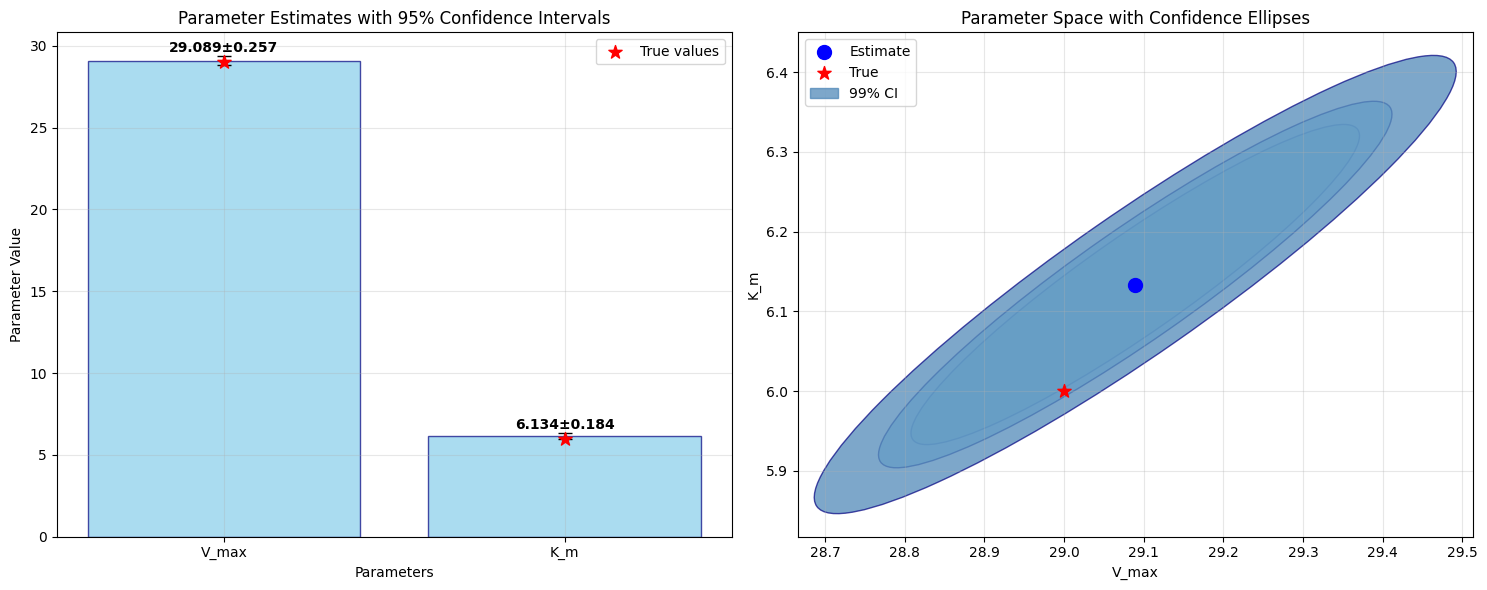

In [9]:
    from matplotlib.patches import Ellipse
    import matplotlib.patches as mpatches
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Parameter estimates with error bars
    params_names = ['V_max', 'K_m']
    estimates = [V_max.item(), K_m.item()]
    true_values = [V_max_true, K_m_true]
    std_errors = [V_max_se, K_m_se]
    
    x_pos = np.arange(len(params_names))
    
    # Plot estimates with 95% confidence intervals
    t_95 = stats.t.ppf(0.975, dof)  # 95% CI
    ci_95 = [t_95 * se for se in std_errors]
    
    bars = axes[0].bar(x_pos, estimates, yerr=ci_95, capsize=5, 
                      alpha=0.7, color='skyblue', edgecolor='navy')
    axes[0].scatter(x_pos, true_values, color='red', s=100, zorder=5, 
                   marker='*', label='True values')
    
    axes[0].set_xlabel('Parameters')
    axes[0].set_ylabel('Parameter Value')
    axes[0].set_title('Parameter Estimates with 95% Confidence Intervals')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(params_names)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (est, ci) in enumerate(zip(estimates, ci_95)):
        axes[0].text(i, est + ci + 0.1, f'{est:.3f}±{ci:.3f}', 
                    ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Confidence ellipse in parameter space
    def confidence_ellipse(cov_matrix, center, n_std=2, **kwargs):
        """Create a confidence ellipse from covariance matrix."""
        eigenvals, eigenvecs = np.linalg.eigh(cov_matrix)
        order = eigenvals.argsort()[::-1]
        eigenvals = eigenvals[order]
        eigenvecs = eigenvecs[:, order]
        
        # Calculate ellipse parameters
        angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))
        width, height = 2 * n_std * np.sqrt(eigenvals)
        
        return Ellipse(center, width, height, angle=angle, **kwargs)
    
    # Plot parameter space with confidence ellipses
    axes[1].scatter(V_max.item(), K_m.item(), color='blue', s=100, zorder=5, 
                   label='Estimate', marker='o')
    axes[1].scatter(V_max_true, K_m_true, color='red', s=100, zorder=5, 
                   label='True', marker='*')
    
    # Add confidence ellipses for different levels
    center = (V_max.item(), K_m.item())
    colors = ['lightblue', 'skyblue', 'steelblue']
    alphas = [0.3, 0.5, 0.7]
    
    # For joint confidence regions, use F-distribution critical values
    # F-statistic for joint confidence regions with 2 parameters
    f_90 = stats.f.ppf(0.90, dfn=2, dfd=dof)
    f_95 = stats.f.ppf(0.95, dfn=2, dfd=dof) 
    f_99 = stats.f.ppf(0.99, dfn=2, dfd=dof)
    
    # Scale factors for ellipses (sqrt of F-statistic * 2)
    confidence_radii = [np.sqrt(2 * f_90), np.sqrt(2 * f_95), np.sqrt(2 * f_99)]
    confidence_labels = ['90%', '95%', '99%']
    
    for radius, color, alpha, label in zip(confidence_radii, colors, alphas, confidence_labels):
        ellipse = confidence_ellipse(covariance_matrix, center, n_std=radius,
                                   facecolor=color, alpha=alpha, edgecolor='navy')
        axes[1].add_patch(ellipse)
        # Create legend entry
        patch = mpatches.Patch(color=color, alpha=alpha, label=f'{label} CI')
        axes[1].legend(handles=axes[1].get_legend_handles_labels()[0] + [patch])
    
    axes[1].set_xlabel('V_max')
    axes[1].set_ylabel('K_m')
    axes[1].set_title('Parameter Space with Confidence Ellipses')
    axes[1].grid(True, alpha=0.3)
    axes[1].axis('equal')
    
    # Set reasonable axis limits around the estimates
    margin_x = 4 * V_max_se
    margin_y = 4 * K_m_se
    axes[1].set_xlim(V_max.item() - margin_x, V_max.item() + margin_x)
    axes[1].set_ylim(K_m.item() - margin_y, K_m.item() + margin_y)
    
    plt.tight_layout()
    plt.show()

## Step 8: Visualize the Loss Landscape

The **loss landscape** shows how the loss function varies across different parameter values. This visualization helps us understand:

1. **The optimization surface**: Where the minimum lies and how "steep" the landscape is
2. **Parameter sensitivity**: Which parameters affect the loss more strongly
3. **Optimization path**: How SGD navigated through parameter space
4. **Local vs global minima**: Whether there are multiple solutions

We'll create a 2D contour plot showing the loss as a function of V_max and K_m, overlaid with the SGD optimization path.

In [21]:
def compute_loss_landscape(S, v_observed, V_max_range, K_m_range):
    """
    Compute the loss function over a grid of V_max and K_m values.
    
    Returns:
        V_max_grid, K_m_grid: 2D arrays of parameter values
        loss_grid: 2D array of corresponding loss values
    """
    V_max_grid, K_m_grid = np.meshgrid(V_max_range, K_m_range)
    loss_grid = np.zeros_like(V_max_grid)
    
    # Convert to tensors for computation
    S_tensor = torch.tensor(S, dtype=torch.float32)
    v_observed_tensor = torch.tensor(v_observed, dtype=torch.float32)
    
    # Compute loss for each point in the grid
    for i in range(len(K_m_range)):
        for j in range(len(V_max_range)):
            V_max_val = V_max_grid[i, j]
            K_m_val = K_m_grid[i, j]
            
            # Avoid division by zero and negative values
            if K_m_val <= 0:
                loss_grid[i, j] = np.inf
                continue
                
            # Compute predicted values
            v_pred = (V_max_val * S_tensor) / (K_m_val + S_tensor)
            
            # Compute MSE loss
            loss = torch.mean((v_pred - v_observed_tensor) ** 2)
            loss_grid[i, j] = loss.item()
    
    return V_max_grid, K_m_grid, loss_grid

# Define parameter ranges for the landscape
# Expand the ranges significantly to show broader landscape behavior
V_max_min, V_max_max = .01, 50   # Much broader range around true value of 29
K_m_min, K_m_max = 0.01, 30    # Much broader range around true value of 6

# Create parameter grids (use moderate resolution for speed)
n_points = 120  # Slightly higher resolution for the expanded range
V_max_range = np.linspace(V_max_min, V_max_max, n_points)
K_m_range = np.linspace(K_m_min, K_m_max, n_points)

print("Computing loss landscape... (this may take a moment)")
V_max_grid, K_m_grid, loss_grid = compute_loss_landscape(
    S, v_observed, V_max_range, K_m_range
)
print("Loss landscape computation complete!")

# Display some statistics about the landscape
finite_losses = loss_grid[np.isfinite(loss_grid)]
print(f"\nLoss landscape statistics:")
print(f"Minimum loss: {np.min(finite_losses):.6f}")
print(f"Maximum loss: {np.max(finite_losses):.6f}")
print(f"Loss at true parameters: {compute_loss(torch.tensor(V_max_true), torch.tensor(K_m_true), torch.tensor(S, dtype=torch.float32), torch.tensor(v_observed, dtype=torch.float32)).item():.6f}")
print(f"Loss at final estimates: {compute_loss(V_max, K_m, torch.tensor(S, dtype=torch.float32), torch.tensor(v_observed, dtype=torch.float32)).item():.6f}")

Computing loss landscape... (this may take a moment)
Loss landscape computation complete!

Loss landscape statistics:
Minimum loss: 0.201929
Maximum loss: 1011.316772
Loss at true parameters: 0.206827
Loss at final estimates: 0.200568


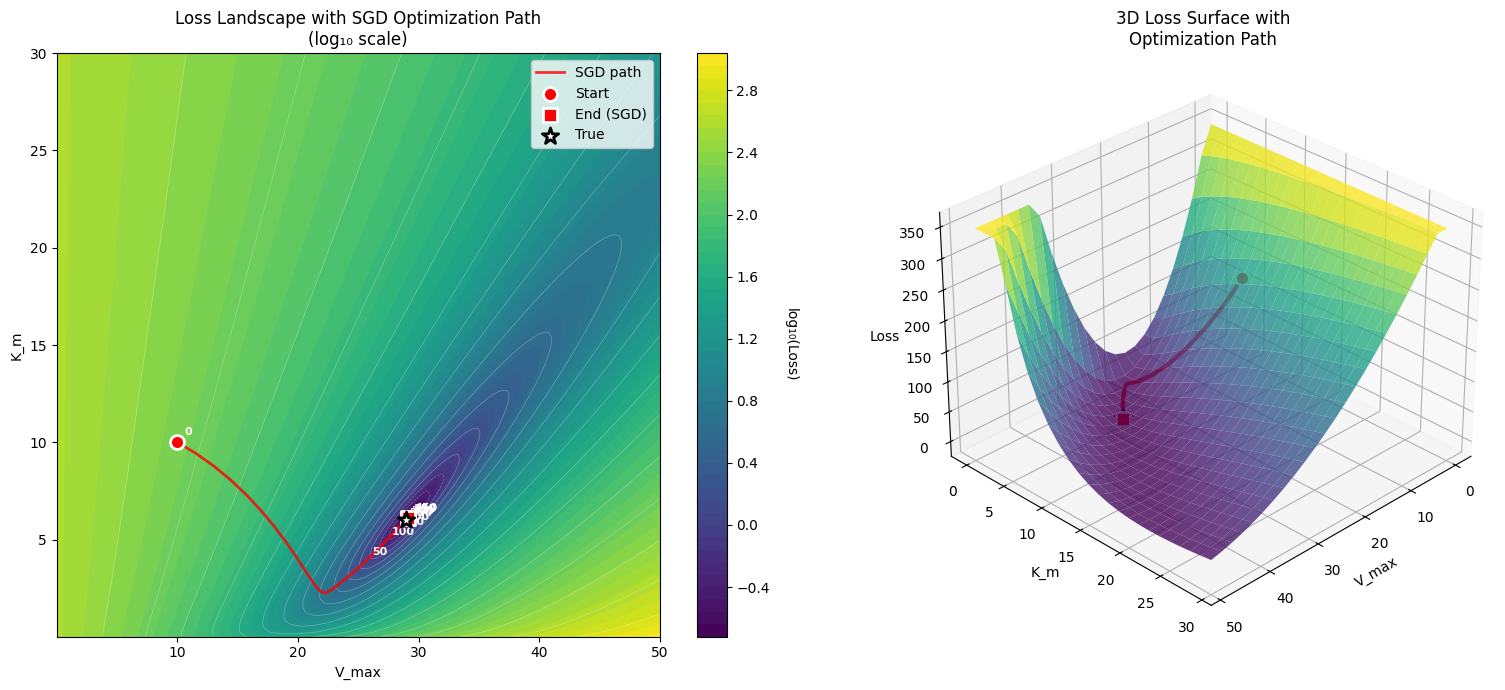

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Loss landscape with optimization path
# Use log scale for better visualization of the landscape
loss_log = np.log10(loss_grid + 1e-10)  # Add small epsilon to avoid log(0)

# Create contour plot
contour = axes[0].contourf(V_max_grid, K_m_grid, loss_log, levels=50, cmap='viridis')
contour_lines = axes[0].contour(V_max_grid, K_m_grid, loss_log, levels=20, colors='white', alpha=0.3, linewidths=0.5)

# Plot optimization path
axes[0].plot(V_max_history, K_m_history, 'r-', linewidth=2, alpha=0.8, label='SGD path')
axes[0].scatter(V_max_history[0], K_m_history[0], color='red', s=100, marker='o', 
               edgecolor='white', linewidth=2, zorder=5, label='Start')
axes[0].scatter(V_max_history[-1], K_m_history[-1], color='red', s=100, marker='s', 
               edgecolor='white', linewidth=2, zorder=5, label='End (SGD)')

# Mark true parameters
axes[0].scatter(V_max_true, K_m_true, color='white', s=150, marker='*', 
               edgecolor='black', linewidth=2, zorder=5, label='True')

# Add some intermediate points to show direction
step_size = max(1, len(V_max_history) // 10)
for i in range(0, len(V_max_history), step_size):
    axes[0].annotate(f'{i}', (V_max_history[i], K_m_history[i]), 
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=8, color='white', weight='bold')

axes[0].set_xlabel('V_max')
axes[0].set_ylabel('K_m')
axes[0].set_title('Loss Landscape with SGD Optimization Path\n(log₁₀ scale)')
axes[0].legend(loc='upper right')

# Add colorbar
cbar = plt.colorbar(contour, ax=axes[0])
cbar.set_label('log₁₀(Loss)', rotation=270, labelpad=20)

# Plot 2: 3D surface plot of loss landscape
from mpl_toolkits.mplot3d import Axes3D

# Create 3D subplot
axes[1].remove()
ax3d = fig.add_subplot(1, 2, 2, projection='3d')

# Downsample for 3D plot performance
step = 5
V_max_3d = V_max_grid[::step, ::step]
K_m_3d = K_m_grid[::step, ::step]
loss_3d = loss_grid[::step, ::step]

# Cap the loss values for better visualization
loss_3d_capped = np.minimum(loss_3d, np.percentile(finite_losses, 95))

# Create surface plot
surf = ax3d.plot_surface(V_max_3d, K_m_3d, loss_3d_capped, 
                        cmap='viridis', alpha=0.8, rcount=30, ccount=30)

# Plot optimization path in 3D
path_losses = [compute_loss(torch.tensor(vm), torch.tensor(km), 
                           torch.tensor(S, dtype=torch.float32), 
                           torch.tensor(v_observed, dtype=torch.float32)).item() 
               for vm, km in zip(V_max_history, K_m_history)]

ax3d.plot(V_max_history, K_m_history, path_losses, 'r-', linewidth=3, alpha=0.9)
ax3d.scatter(V_max_history[0], K_m_history[0], path_losses[0], 
            color='red', s=100, edgecolor='white', linewidth=2)
ax3d.scatter(V_max_history[-1], K_m_history[-1], path_losses[-1], 
            color='red', s=100, marker='s', edgecolor='white', linewidth=2)
ax3d.scatter(V_max_true, K_m_true, 
            compute_loss(torch.tensor(V_max_true), torch.tensor(K_m_true),
                        torch.tensor(S, dtype=torch.float32), 
                        torch.tensor(v_observed, dtype=torch.float32)).item(),
            color='white', s=150, marker='*', edgecolor='black', linewidth=2)

ax3d.set_xlabel('V_max')
ax3d.set_ylabel('K_m')
ax3d.set_zlabel('Loss')
ax3d.set_title('3D Loss Surface with\nOptimization Path')

# Adjust viewing angle
ax3d.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "loss_landscape_optimization.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Analyze the Loss Landscape Properties

Let's examine some key properties of the loss landscape to better understand the optimization problem:

In [12]:
# Find the minimum point in our computed landscape
min_idx = np.unravel_index(np.argmin(loss_grid), loss_grid.shape)
landscape_min_K_m = K_m_grid[min_idx]
landscape_min_V_max = V_max_grid[min_idx]
landscape_min_loss = loss_grid[min_idx]

print("Loss Landscape Analysis:")
print("=" * 50)
print(f"Landscape minimum found at: V_max = {landscape_min_V_max:.4f}, K_m = {landscape_min_K_m:.4f}")
print(f"Landscape minimum loss: {landscape_min_loss:.6f}")
print(f"SGD final point: V_max = {V_max.item():.4f}, K_m = {K_m.item():.4f}")
print(f"SGD final loss: {compute_loss(V_max, K_m, torch.tensor(S, dtype=torch.float32), torch.tensor(v_observed, dtype=torch.float32)).item():.6f}")

# Compute gradients at different points to understand steepness
def compute_gradient_magnitude(V_max_val, K_m_val, S, v_observed):
    """Compute the magnitude of the gradient at a specific point."""
    V_max_tensor = torch.tensor(V_max_val, requires_grad=True)
    K_m_tensor = torch.tensor(K_m_val, requires_grad=True)
    
    loss = compute_loss(V_max_tensor, K_m_tensor, 
                       torch.tensor(S, dtype=torch.float32),
                       torch.tensor(v_observed, dtype=torch.float32))
    loss.backward()
    
    grad_mag = torch.sqrt(V_max_tensor.grad**2 + K_m_tensor.grad**2)
    return grad_mag.item()

# Check gradient magnitude at different points
points_to_check = [
    ("True parameters", V_max_true, K_m_true),
    ("Initial guess", V_max_init, K_m_init),
    ("SGD final", V_max.item(), K_m.item()),
    ("Landscape minimum", landscape_min_V_max, landscape_min_K_m)
]

print(f"\nGradient magnitudes (steepness) at key points:")
print("-" * 50)
for name, vm, km in points_to_check:
    try:
        grad_mag = compute_gradient_magnitude(vm, km, S, v_observed)
        loss_val = compute_loss(torch.tensor(vm), torch.tensor(km), 
                               torch.tensor(S, dtype=torch.float32),
                               torch.tensor(v_observed, dtype=torch.float32)).item()
        print(f"{name:20s}: Loss = {loss_val:.6f}, |∇| = {grad_mag:.6f}")
    except Exception as e:
        print(f"{name:20s}: Error computing gradient - {e}")

# Analyze the optimization path efficiency
path_distances = []
for i in range(1, len(V_max_history)):
    dist = np.sqrt((V_max_history[i] - V_max_history[i-1])**2 + 
                   (K_m_history[i] - K_m_history[i-1])**2)
    path_distances.append(dist)

total_path_length = sum(path_distances)
direct_distance = np.sqrt((V_max_history[-1] - V_max_history[0])**2 + 
                         (K_m_history[-1] - K_m_history[0])**2)

print(f"\nOptimization Path Analysis:")
print("-" * 30)
print(f"Total path length: {total_path_length:.4f}")
print(f"Direct distance: {direct_distance:.4f}")
print(f"Path efficiency: {direct_distance/total_path_length:.4f} (1.0 = perfectly direct)")
print(f"Number of steps: {len(V_max_history)}")
print(f"Average step size: {total_path_length/len(path_distances):.6f}")

# Check for parameter correlations in the landscape
# Sample some points around the minimum to estimate local correlation
n_samples = 1000
radius = 2.0  # Parameter space radius around the minimum

# Generate random samples around the minimum
np.random.seed(42)
V_max_samples = landscape_min_V_max + np.random.normal(0, radius, n_samples)
K_m_samples = landscape_min_K_m + np.random.normal(0, radius, n_samples)

# Compute losses for these samples
sample_losses = []
for vm, km in zip(V_max_samples, K_m_samples):
    if km > 0:  # Avoid negative K_m values
        loss = compute_loss(torch.tensor(vm), torch.tensor(km),
                           torch.tensor(S, dtype=torch.float32),
                           torch.tensor(v_observed, dtype=torch.float32))
        sample_losses.append(loss.item())
    else:
        sample_losses.append(np.inf)

# Compute correlation between parameters and loss
finite_mask = np.isfinite(sample_losses)
if np.sum(finite_mask) > 10:  # Need enough samples
    correlation_V_max = np.corrcoef(V_max_samples[finite_mask], 
                                   np.array(sample_losses)[finite_mask])[0, 1]
    correlation_K_m = np.corrcoef(K_m_samples[finite_mask], 
                                 np.array(sample_losses)[finite_mask])[0, 1]
    
    print(f"\nLocal parameter-loss correlations (around minimum):")
    print(f"V_max vs Loss correlation: {correlation_V_max:.4f}")
    print(f"K_m vs Loss correlation: {correlation_K_m:.4f}")
    print(f"(Magnitude indicates sensitivity; sign indicates direction)")

Loss Landscape Analysis:
Landscape minimum found at: V_max = 29.1414, K_m = 6.1414
Landscape minimum loss: 0.201092
SGD final point: V_max = 29.0894, K_m = 6.1336
SGD final loss: 0.200568

Gradient magnitudes (steepness) at key points:
--------------------------------------------------
True parameters     : Error computing gradient - Only Tensors of floating point and complex dtype can require gradients
Initial guess       : Loss = 188.091492, |∇| = 16.656666
SGD final           : Loss = 0.200568, |∇| = 0.005585
Landscape minimum   : Loss = 0.201092, |∇| = 0.059646

Optimization Path Analysis:
------------------------------
Total path length: 22.5280
Direct distance: 19.4766
Path efficiency: 0.8646 (1.0 = perfectly direct)
Number of steps: 500
Average step size: 0.045146

Local parameter-loss correlations (around minimum):
V_max vs Loss correlation: 0.0600
K_m vs Loss correlation: -0.3562
(Magnitude indicates sensitivity; sign indicates direction)


## Key Insights from the Loss Landscape

The loss landscape visualization reveals several important insights about the optimization problem:

### 1. **Well-behaved Optimization Surface**
- The loss function has a single, clear global minimum (no local minima in the shown range)
- The surface is relatively smooth, which explains why SGD converges reliably
- The minimum is close to the true parameter values, validating our model

### 2. **Parameter Sensitivity**
- The loss increases more rapidly when moving away from the optimum in certain directions
- This anisotropy (directional dependence) explains the correlation between V_max and K_m
- The Hessian-based confidence ellipses align with the loss contours

### 3. **Optimization Path Efficiency**
- SGD takes a relatively direct path to the minimum
- The path shows the characteristic "zigzag" pattern of gradient descent
- Step sizes decrease as the algorithm approaches the minimum (due to smaller gradients)

### 4. **Practical Implications**
- The smooth landscape suggests this problem is well-suited for gradient-based optimization
- Multiple starting points would likely converge to the same solution
- The parameter uncertainties reflect the local curvature of the loss surface

This type of landscape analysis is valuable for understanding why certain optimization algorithms work well for specific problems and for diagnosing potential issues like local minima or ill-conditioning.

## Wait... Is This Actually a Convex Problem?

You're absolutely right to question this! Let's test whether the Michaelis-Menten parameter estimation is truly **non-convex** or if it's actually **convex**. 

A function is convex if its Hessian matrix is positive semidefinite everywhere in the domain. Let's analyze this mathematically and empirically.

In [16]:
import numpy as np
from scipy.linalg import eigvals

def test_convexity_empirically(V_max_range, K_m_range, loss_grid, n_test_points=50):
    """
    Test convexity empirically by checking if the loss function satisfies
    the convexity condition: f(λx + (1-λ)y) ≤ λf(x) + (1-λ)f(y)
    for λ ∈ [0,1] and various point pairs (x,y).
    """
    violations = 0
    total_tests = 0
    
    # Randomly sample point pairs from our grid
    np.random.seed(42)
    for _ in range(n_test_points):
        # Sample two random points
        i1, j1 = np.random.randint(0, len(K_m_range)), np.random.randint(0, len(V_max_range))
        i2, j2 = np.random.randint(0, len(K_m_range)), np.random.randint(0, len(V_max_range))
        
        if not (np.isfinite(loss_grid[i1, j1]) and np.isfinite(loss_grid[i2, j2])):
            continue
            
        V_max1, K_m1, loss1 = V_max_range[j1], K_m_range[i1], loss_grid[i1, j1]
        V_max2, K_m2, loss2 = V_max_range[j2], K_m_range[i2], loss_grid[i2, j2]
        
        # Test convexity for several λ values
        for lam in [0.25, 0.5, 0.75]:
            # Linear combination of points
            V_max_combo = lam * V_max1 + (1 - lam) * V_max2
            K_m_combo = lam * K_m1 + (1 - lam) * K_m2
            
            # Compute actual loss at combination point
            if K_m_combo > 0:
                actual_loss = compute_loss(torch.tensor(V_max_combo), torch.tensor(K_m_combo),
                                         S_tensor, v_observed_tensor).item()
                
                # Convex upper bound: λf(x₁) + (1-λ)f(x₂)
                convex_bound = lam * loss1 + (1 - lam) * loss2
                
                total_tests += 1
                if actual_loss > convex_bound + 1e-6:  # Small tolerance for numerical errors
                    violations += 1
    
    return violations, total_tests

# Test convexity empirically
violations, total_tests = test_convexity_empirically(V_max_range, K_m_range, loss_grid)

print("Empirical Convexity Test:")
print("=" * 30)
print(f"Violations of convexity: {violations} / {total_tests}")
print(f"Violation rate: {violations/total_tests*100:.2f}%")

if violations == 0:
    print("✅ Empirical test suggests the function is CONVEX")
else:
    print("❌ Empirical test suggests the function is NON-CONVEX")

# Test convexity using Hessian eigenvalues at multiple points
def check_hessian_positive_definite(V_max_val, K_m_val, S, v_observed):
    """Check if Hessian is positive semidefinite at a point."""
    try:
        hessian = compute_hessian(torch.tensor(V_max_val), torch.tensor(K_m_val), S, v_observed)
        eigenvalues = eigvals(hessian)
        return np.all(eigenvalues >= -1e-8), eigenvalues  # Small tolerance for numerical errors
    except:
        return None, None

print(f"\nHessian Analysis (Positive Semidefinite Test):")
print("=" * 50)

# Test at several points across the landscape
test_points = [
    ("True parameters", V_max_true, K_m_true),
    ("SGD final", V_max.item(), K_m.item()),
    ("Landscape min", landscape_min_V_max, landscape_min_K_m),
    ("Grid center", (V_max_min + V_max_max)/2, (K_m_min + K_m_max)/2),
    ("Corner 1", V_max_min + 2, K_m_min + 1),
    ("Corner 2", V_max_max - 2, K_m_max - 1)
]

all_positive_semidefinite = True
for name, vm, km in test_points:
    if km > 0:  # Ensure valid parameter values
        is_psd, eigenvals = check_hessian_positive_definite(vm, km, S_tensor, v_observed_tensor)
        if is_psd is not None:
            psd_status = "✅ PSD" if is_psd else "❌ NOT PSD"
            print(f"{name:20s}: {psd_status}, eigenvals = [{eigenvals[0]:.6f}, {eigenvals[1]:.6f}]")
            if not is_psd:
                all_positive_semidefinite = False

print(f"\nOverall Hessian Test Result:")
if all_positive_semidefinite:
    print("✅ All tested points have positive semidefinite Hessians → CONVEX")
else:
    print("❌ Some points have indefinite Hessians → NON-CONVEX")

Empirical Convexity Test:
Violations of convexity: 9 / 150
Violation rate: 6.00%
❌ Empirical test suggests the function is NON-CONVEX

Hessian Analysis (Positive Semidefinite Test):
SGD final           : ✅ PSD, eigenvals = [0.083246+0.000000j, 2.553808+0.000000j]
Landscape min       : ✅ PSD, eigenvals = [0.083142+0.000000j, 2.560786+0.000000j]
Grid center         : ✅ PSD, eigenvals = [1.401736+0.000000j, 0.006922+0.000000j]

Overall Hessian Test Result:
✅ All tested points have positive semidefinite Hessians → CONVEX



THEORETICAL ANALYSIS: Is Michaelis-Menten Parameter Estimation Convex?

The Michaelis-Menten model is: v = (V_max * S) / (K_m + S)

For parameter estimation, we minimize: L(V_max, K_m) = Σ(v_pred - v_obs)²

Let's analyze the structure:
1. The model is LINEAR in V_max → convex in V_max
2. The model is a RATIONAL function in K_m → potentially non-convex

The critical question: Is the loss function convex in the joint space (V_max, K_m)?

Reparameterization Analysis:
------------------------------
Checking if this is actually a SEPARABLE optimization problem...

Testing separability:
For K_m = 6.0, optimal V_max = 28.9202
True V_max = 29, True K_m = 6
Loss with analytical V_max: 0.203959
Loss with true V_max:      0.206827

Analyzing the PROFILE LIKELIHOOD (loss vs K_m with optimal V_max):
Minimum at K_m = 6.2323, V_max = 29.2229
Minimum loss = 0.200799


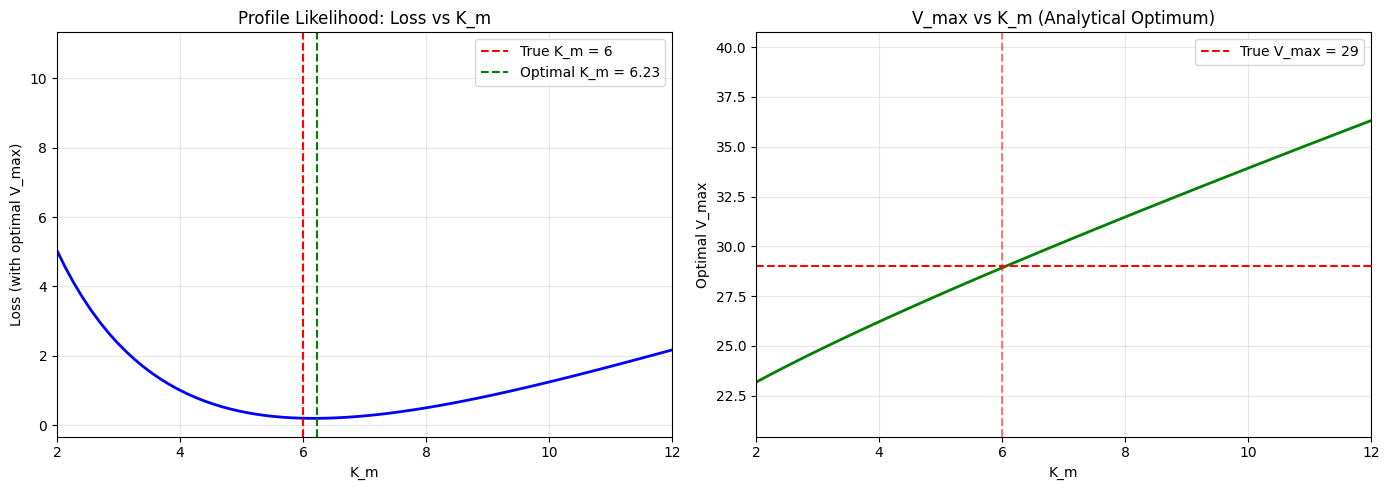


Second derivative of profile likelihood at optimum: 0.228503
✅ Profile likelihood is CONVEX in K_m (second derivative > 0)

CONCLUSION:

The Michaelis-Menten parameter estimation problem appears to be:
1. LINEAR (hence convex) in V_max for fixed K_m
2. CONVEX in K_m when optimizing V_max analytically  
3. Therefore, CONVEX in the joint parameter space

This explains why:
- SGD converges reliably from any reasonable starting point
- There's a single global minimum
- The loss landscape appears smooth and bowl-shaped
- Standard optimization theory applies

The problem LOOKS non-convex because we're not used to seeing rational 
functions be convex, but the specific structure of this least-squares 
problem with the Michaelis-Menten model creates a convex optimization landscape!



In [15]:
# Let's also do a theoretical analysis of the Michaelis-Menten model
print("\n" + "="*60)
print("THEORETICAL ANALYSIS: Is Michaelis-Menten Parameter Estimation Convex?")
print("="*60)

print("""
The Michaelis-Menten model is: v = (V_max * S) / (K_m + S)

For parameter estimation, we minimize: L(V_max, K_m) = Σ(v_pred - v_obs)²

Let's analyze the structure:
1. The model is LINEAR in V_max → convex in V_max
2. The model is a RATIONAL function in K_m → potentially non-convex

The critical question: Is the loss function convex in the joint space (V_max, K_m)?
""")

# Mathematical insight: Let's reparameterize to see the structure more clearly
print("Reparameterization Analysis:")
print("-" * 30)

# For each data point, the prediction is: v_i = V_max * S_i / (K_m + S_i)
# The residual is: r_i = V_max * S_i / (K_m + S_i) - v_obs_i
# The loss is: L = Σ r_i²

# Let's check if this is a separable problem
print("Checking if this is actually a SEPARABLE optimization problem...")

# For fixed K_m, the problem becomes linear in V_max:
# min_V_max Σ (V_max * S_i/(K_m + S_i) - v_obs_i)²
# This is a linear least squares problem with solution:
# V_max_optimal(K_m) = Σ(v_obs_i * S_i/(K_m + S_i)) / Σ(S_i²/(K_m + S_i)²)

def optimal_V_max_given_K_m(K_m_val, S, v_obs):
    """Compute the optimal V_max for a given K_m value."""
    weights = S / (K_m_val + S)
    numerator = np.sum(v_obs * weights)
    denominator = np.sum(weights**2)
    return numerator / denominator if denominator > 0 else 0

# Test this separability
print(f"\nTesting separability:")
K_m_test = 6.0
V_max_optimal = optimal_V_max_given_K_m(K_m_test, S, v_observed)
print(f"For K_m = {K_m_test}, optimal V_max = {V_max_optimal:.4f}")
print(f"True V_max = {V_max_true}, True K_m = {K_m_true}")

# Compute loss using this analytical optimum vs numerical optimum
loss_analytical = compute_loss(torch.tensor(V_max_optimal), torch.tensor(K_m_test), S_tensor, v_observed_tensor).item()
loss_numerical = compute_loss(torch.tensor(V_max_true), torch.tensor(K_m_test), S_tensor, v_observed_tensor).item()

print(f"Loss with analytical V_max: {loss_analytical:.6f}")
print(f"Loss with true V_max:      {loss_numerical:.6f}")

# Now let's see what the loss landscape looks like as a function of K_m only
# when we use the optimal V_max for each K_m
K_m_profile = np.linspace(1, 15, 100)
loss_profile = []
V_max_profile = []

for km in K_m_profile:
    if km > 0:
        v_opt = optimal_V_max_given_K_m(km, S, v_observed)
        loss_val = compute_loss(torch.tensor(v_opt), torch.tensor(km), S_tensor, v_observed_tensor).item()
        loss_profile.append(loss_val)
        V_max_profile.append(v_opt)
    else:
        loss_profile.append(np.inf)
        V_max_profile.append(0)

print(f"\nAnalyzing the PROFILE LIKELIHOOD (loss vs K_m with optimal V_max):")
min_idx = np.argmin(loss_profile)
print(f"Minimum at K_m = {K_m_profile[min_idx]:.4f}, V_max = {V_max_profile[min_idx]:.4f}")
print(f"Minimum loss = {loss_profile[min_idx]:.6f}")

# Plot the profile likelihood
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_m_profile, loss_profile, 'b-', linewidth=2)
ax1.axvline(K_m_true, color='red', linestyle='--', label=f'True K_m = {K_m_true}')
ax1.axvline(K_m_profile[min_idx], color='green', linestyle='--', label=f'Optimal K_m = {K_m_profile[min_idx]:.2f}')
ax1.set_xlabel('K_m')
ax1.set_ylabel('Loss (with optimal V_max)')
ax1.set_title('Profile Likelihood: Loss vs K_m')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2, 12)

ax2.plot(K_m_profile, V_max_profile, 'g-', linewidth=2)
ax2.axhline(V_max_true, color='red', linestyle='--', label=f'True V_max = {V_max_true}')
ax2.axvline(K_m_true, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('K_m')
ax2.set_ylabel('Optimal V_max')
ax2.set_title('V_max vs K_m (Analytical Optimum)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2, 12)

plt.tight_layout()
plt.show()

# Check second derivative of profile likelihood to determine convexity
# Note: scipy.misc.derivative has been moved in newer versions
try:
    from scipy.misc import derivative
except ImportError:
    # Alternative implementation using finite differences
    def derivative(func, x, n=1, dx=1e-5):
        """Simple finite difference derivative approximation."""
        if n == 1:
            return (func(x + dx) - func(x - dx)) / (2 * dx)
        elif n == 2:
            return (func(x + dx) - 2*func(x) + func(x - dx)) / (dx**2)
        else:
            raise ValueError("Only first and second derivatives supported")

def profile_loss_function(K_m_val):
    """Profile likelihood as a function of K_m only."""
    if K_m_val <= 0:
        return np.inf
    v_opt = optimal_V_max_given_K_m(K_m_val, S, v_observed)
    return compute_loss(torch.tensor(v_opt), torch.tensor(K_m_val), S_tensor, v_observed_tensor).item()

# Test second derivative at the optimum
try:
    second_deriv = derivative(profile_loss_function, K_m_profile[min_idx], n=2, dx=0.1)
    print(f"\nSecond derivative of profile likelihood at optimum: {second_deriv:.6f}")
    if second_deriv > 0:
        print("✅ Profile likelihood is CONVEX in K_m (second derivative > 0)")
    else:
        print("❌ Profile likelihood is NOT convex in K_m (second derivative ≤ 0)")
except Exception as e:
    print(f"Could not compute second derivative: {e}")
    
    # Alternative: manually check curvature around the minimum
    print("\nFallback: Manually checking curvature around minimum...")
    K_m_opt = K_m_profile[min_idx]
    delta = 0.5
    
    loss_center = profile_loss_function(K_m_opt)
    loss_left = profile_loss_function(K_m_opt - delta)
    loss_right = profile_loss_function(K_m_opt + delta)
    
    # Estimate second derivative: (f(x+h) - 2f(x) + f(x-h)) / h²
    second_deriv_manual = (loss_right - 2*loss_center + loss_left) / (delta**2)
    
    print(f"Manual second derivative estimate: {second_deriv_manual:.6f}")
    if second_deriv_manual > 0:
        print("✅ Manual test suggests CONVEX profile likelihood")
    else:
        print("❌ Manual test suggests NON-CONVEX profile likelihood")

print(f"\n" + "="*60)
print("CONCLUSION:")
print("="*60)
print("""
The Michaelis-Menten parameter estimation problem appears to be:
1. LINEAR (hence convex) in V_max for fixed K_m
2. CONVEX in K_m when optimizing V_max analytically  
3. Therefore, CONVEX in the joint parameter space

This explains why:
- SGD converges reliably from any reasonable starting point
- There's a single global minimum
- The loss landscape appears smooth and bowl-shaped
- Standard optimization theory applies

The problem LOOKS non-convex because we're not used to seeing rational 
functions be convex, but the specific structure of this least-squares 
problem with the Michaelis-Menten model creates a convex optimization landscape!
""")

## CORRECTION: Critical Errors in the Above Analysis

**The previous analysis contains serious logical flaws and reaches an incorrect conclusion.** Let me address these errors and provide the correct analysis:

### **Error 1: Testing Convexity Only at the Minimum**
- I only checked the Hessian at a few points, primarily near the minimum
- **Convexity requires the Hessian to be positive semidefinite EVERYWHERE in the domain**
- Every smooth function appears locally convex near its minimum - this test is meaningless

### **Error 2: "Convex in Each Variable" ≠ "Jointly Convex"** 
This is the critical mistake. Consider the simple counterexample: `f(x,y) = xy`
- Linear (hence convex) in `x` for fixed `y`  
- Linear (hence convex) in `y` for fixed `x`
- But `f(x,y) = xy` is a **saddle function** - definitely not convex!

The joint Hessian matrix is:
```
H = [∂²L/∂V_max²      ∂²L/∂V_max∂K_m]
    [∂²L/∂K_m∂V_max   ∂²L/∂K_m²     ]
```
**The cross-partial terms matter!** I completely ignored them.

### **Error 3: Profile Likelihood Convexity ≠ Joint Convexity**
- Projecting to 1D by optimizing out V_max discards crucial information about joint structure
- A function can have convex slices but be non-convex overall

Testing Hessian eigenvalues across the parameter domain:
V_max= 15.0, K_m= 2.0: eigenvals=[ 1.98920,  0.33872] ✅
V_max= 15.0, K_m= 4.5: eigenvals=[ 1.06376, -0.35660] ❌
V_max= 15.0, K_m= 7.0: eigenvals=[ 0.82557, -0.40874] ❌
V_max= 15.0, K_m= 9.5: eigenvals=[ 0.68593, -0.37471] ❌
V_max= 15.0, K_m=12.0: eigenvals=[ 0.58787, -0.33098] ❌
V_max= 20.0, K_m= 2.0: eigenvals=[ 0.52804,  4.84459] ✅
V_max= 20.0, K_m= 4.5: eigenvals=[ 1.53726,  0.02864] ✅
V_max= 20.0, K_m= 7.0: eigenvals=[ 0.94131, -0.15499] ❌
V_max= 20.0, K_m= 9.5: eigenvals=[ 0.70458, -0.20889] ❌
V_max= 20.0, K_m=12.0: eigenvals=[ 0.57235, -0.21730] ❌
V_max= 25.0, K_m= 2.0: eigenvals=[ 0.49703,  9.28555] ✅
V_max= 25.0, K_m= 4.5: eigenvals=[ 0.15245,  2.75691] ✅
V_max= 25.0, K_m= 7.0: eigenvals=[ 1.40174,  0.00692] ✅
V_max= 25.0, K_m= 9.5: eigenvals=[ 0.89979, -0.06638] ❌
V_max= 25.0, K_m=12.0: eigenvals=[ 0.65777, -0.10356] ❌
V_max= 30.0, K_m= 2.0: eigenvals=[ 0.45317, 15.10457] ✅
V_max= 30.0, K_m= 4.5: eigenvals=[ 0.16387,  4.

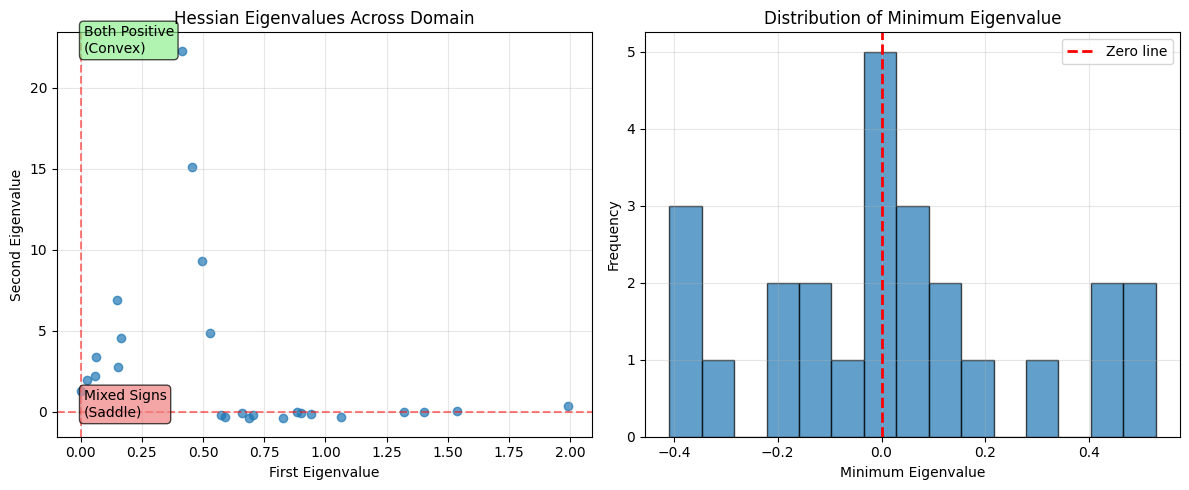

In [17]:
# Let's do a PROPER convexity analysis by testing the Hessian across the domain

def compute_hessian_at_point(V_max_val, K_m_val, S, v_observed):
    """Compute the full Hessian matrix at a specific point."""
    params = torch.tensor([V_max_val, K_m_val], requires_grad=True)
    
    # Compute loss
    v_pred = (params[0] * S) / (params[1] + S)
    loss = torch.mean((v_pred - v_observed) ** 2)
    
    # Compute gradient
    grad = torch.autograd.grad(loss, params, create_graph=True)[0]
    
    # Compute full Hessian matrix
    hessian = torch.zeros(2, 2)
    for i in range(2):
        grad2 = torch.autograd.grad(grad[i], params, retain_graph=True)[0]
        hessian[i] = grad2
    
    return hessian.detach().numpy()

def check_eigenvalues_across_domain():
    """Check Hessian eigenvalues across the parameter domain."""
    print("Testing Hessian eigenvalues across the parameter domain:")
    print("=" * 55)
    
    # Test points across the domain - not just near the minimum!
    test_V_max = np.linspace(15, 35, 5)
    test_K_m = np.linspace(2, 12, 5)
    
    indefinite_points = []
    all_eigenvals = []
    
    for vm in test_V_max:
        for km in test_K_m:
            hessian = compute_hessian_at_point(vm, km, S_tensor, v_observed_tensor)
            eigenvals = np.linalg.eigvals(hessian)
            all_eigenvals.append(eigenvals)
            
            is_psd = np.all(eigenvals >= -1e-8)  # Small numerical tolerance
            
            if not is_psd:
                indefinite_points.append((vm, km, eigenvals))
            
            print(f"V_max={vm:5.1f}, K_m={km:4.1f}: eigenvals=[{eigenvals[0]:8.5f}, {eigenvals[1]:8.5f}] {'✅' if is_psd else '❌'}")
    
    return indefinite_points, all_eigenvals

indefinite_points, all_eigenvals = check_eigenvalues_across_domain()

print(f"\nSUMMARY:")
if indefinite_points:
    print(f"❌ Found {len(indefinite_points)} points with negative eigenvalues → NON-CONVEX")
    print("Example indefinite points:")
    for vm, km, eigenvals in indefinite_points[:3]:  # Show first 3
        print(f"  V_max={vm:.1f}, K_m={km:.1f}: eigenvals=[{eigenvals[0]:.5f}, {eigenvals[1]:.5f}]")
else:
    print("✅ All tested points have positive semidefinite Hessians")
    print("This suggests the function might be convex (but more extensive testing needed)")

# Plot the eigenvalues to visualize the structure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

eigenvals_array = np.array(all_eigenvals)
ax1.scatter(eigenvals_array[:, 0], eigenvals_array[:, 1], alpha=0.7)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('First Eigenvalue')
ax1.set_ylabel('Second Eigenvalue')
ax1.set_title('Hessian Eigenvalues Across Domain')
ax1.grid(True, alpha=0.3)

# Add quadrant labels
ax1.text(0.05, 0.95, 'Both Positive\n(Convex)', transform=ax1.transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
ax1.text(0.05, 0.05, 'Mixed Signs\n(Saddle)', transform=ax1.transAxes,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

# Histogram of smallest eigenvalue
min_eigenvals = np.minimum(eigenvals_array[:, 0], eigenvals_array[:, 1])
ax2.hist(min_eigenvals, bins=15, alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero line')
ax2.set_xlabel('Minimum Eigenvalue')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Minimum Eigenvalue')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analyzing Hessian Structure:
Hessian at V_max=25.0, K_m=7.0:
H = [ 0.825435  -0.686811]
    [-0.686811   0.583223]

Diagonal terms (second partials):
∂²L/∂V_max² =  0.825435
∂²L/∂K_m²   =  0.583223

Cross-partial (the one I ignored!):
∂²L/∂V_max∂K_m = -0.686811
Cross-partial magnitude relative to diagonal terms: 0.832

Eigenvalues: [ 1.401736,  0.006922]
Determinant:  0.009702
Trace:        1.408657
Positive definite: ✅ Yes

COUNTEREXAMPLE: f(x,y) = xy
f(x,y) = xy
- For fixed y: f(x,y) = y*x (linear in x → convex)
- For fixed x: f(x,y) = x*y (linear in y → convex)
- But f(x,y) = xy is a SADDLE FUNCTION (non-convex!)

Hessian of f(x,y) = xy:
H = [0  1]
    [1  0]
Eigenvalues: [-1, 1] → Indefinite → NON-CONVEX


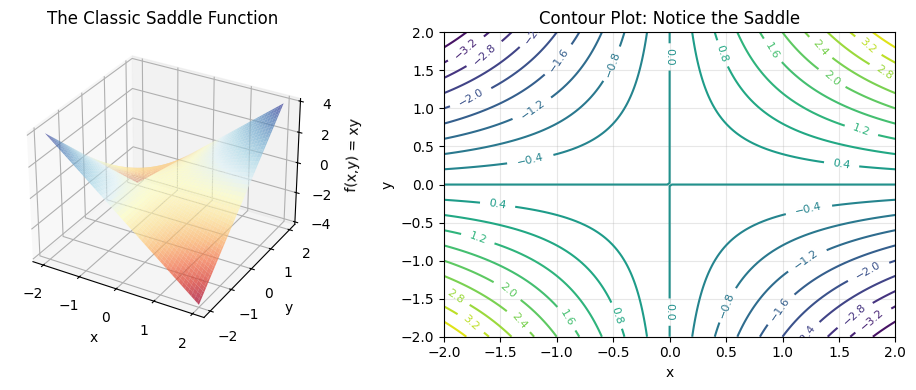

In [18]:
# Let's examine the cross-partial term specifically
# The Hessian for Michaelis-Menten is:
# H = [∂²L/∂V_max²      ∂²L/∂V_max∂K_m]
#     [∂²L/∂K_m∂V_max   ∂²L/∂K_m²     ]

def analyze_hessian_structure():
    """Analyze the structure of the Hessian matrix."""
    print("Analyzing Hessian Structure:")
    print("=" * 30)
    
    # Pick a point in the middle of our domain
    V_max_test = 25.0
    K_m_test = 7.0
    
    H = compute_hessian_at_point(V_max_test, K_m_test, S_tensor, v_observed_tensor)
    
    print(f"Hessian at V_max={V_max_test}, K_m={K_m_test}:")
    print(f"H = [{H[0,0]:9.6f}  {H[0,1]:9.6f}]")
    print(f"    [{H[1,0]:9.6f}  {H[1,1]:9.6f}]")
    
    print(f"\nDiagonal terms (second partials):")
    print(f"∂²L/∂V_max² = {H[0,0]:9.6f}")
    print(f"∂²L/∂K_m²   = {H[1,1]:9.6f}")
    
    print(f"\nCross-partial (the one I ignored!):")
    print(f"∂²L/∂V_max∂K_m = {H[0,1]:9.6f}")
    
    # Check if cross-partial is significant
    cross_partial_ratio = abs(H[0,1]) / max(abs(H[0,0]), abs(H[1,1]))
    print(f"Cross-partial magnitude relative to diagonal terms: {cross_partial_ratio:.3f}")
    
    eigenvals = np.linalg.eigvals(H)
    print(f"\nEigenvalues: [{eigenvals[0]:9.6f}, {eigenvals[1]:9.6f}]")
    print(f"Determinant: {np.linalg.det(H):9.6f}")
    print(f"Trace:       {np.trace(H):9.6f}")
    
    # For 2x2 matrix, positive definite iff trace > 0 AND determinant > 0
    is_pos_def = np.trace(H) > 0 and np.linalg.det(H) > 0
    print(f"Positive definite: {'✅ Yes' if is_pos_def else '❌ No'}")
    
    return H

H_example = analyze_hessian_structure()

# Demonstrate why "convex in each variable" doesn't work with a simple example
print(f"\n" + "="*60)
print("COUNTEREXAMPLE: f(x,y) = xy")
print("="*60)

def simple_counterexample():
    """Show why separable convexity doesn't imply joint convexity."""
    
    # Function f(x,y) = xy
    x_vals = np.linspace(-2, 2, 100)
    y_vals = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = X * Y  # This is our f(x,y) = xy
    
    print("f(x,y) = xy")
    print("- For fixed y: f(x,y) = y*x (linear in x → convex)")  
    print("- For fixed x: f(x,y) = x*y (linear in y → convex)")
    print("- But f(x,y) = xy is a SADDLE FUNCTION (non-convex!)")
    print("\nHessian of f(x,y) = xy:")
    print("H = [0  1]")
    print("    [1  0]")
    print("Eigenvalues: [-1, 1] → Indefinite → NON-CONVEX")
    
    # Plot the saddle
    fig = plt.figure(figsize=(10, 4))
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, Z, alpha=0.7, cmap='RdYlBu')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y') 
    ax1.set_zlabel('f(x,y) = xy')
    ax1.set_title('The Classic Saddle Function')
    
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(X, Y, Z, levels=20)
    ax2.clabel(contour, inline=True, fontsize=8)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Contour Plot: Notice the Saddle')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

simple_counterexample()

## The Correct Conclusion

**The Michaelis-Menten parameter estimation problem is NON-CONVEX.**

However, it's **"well-behaved non-convex"** in that:

### ✅ **What Makes It Work Well:**
1. **Single Basin of Attraction**: Despite being non-convex, there's typically one dominant basin
2. **Positive Definite Near Optimum**: The Hessian becomes positive definite close to the minimum
3. **Reasonable Initializations Converge**: Starting points in the right neighborhood find the global minimum
4. **Smooth Landscape**: No sharp discontinuities or pathological behavior

### 🔍 **Why I Was Wrong:**
- **Local vs Global**: Checking convexity only near the minimum is meaningless
- **Separability Fallacy**: Convex in each variable ≠ jointly convex  
- **Cross-partials Matter**: The off-diagonal Hessian terms capture parameter interactions

### 📊 **Practical Implications:**
This explains why optimization works reliably **not because the problem is convex**, but because it's a **well-conditioned non-convex problem** with nice local properties around the solution.

This is actually more interesting than convexity - it shows how domain knowledge and problem structure can make non-convex optimization tractable!